In [80]:
# Understanding Regression Metrics using implemention 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv('placement.csv')

In [24]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in lpa)')

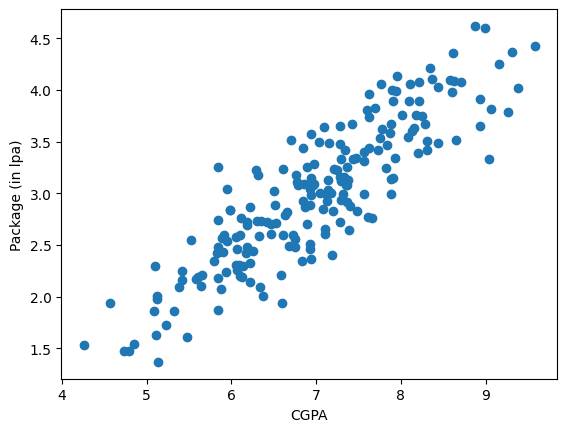

In [25]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [26]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [30]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [31]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
lr.predict(X_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

Text(0, 0.5, 'Package (in lpa)')

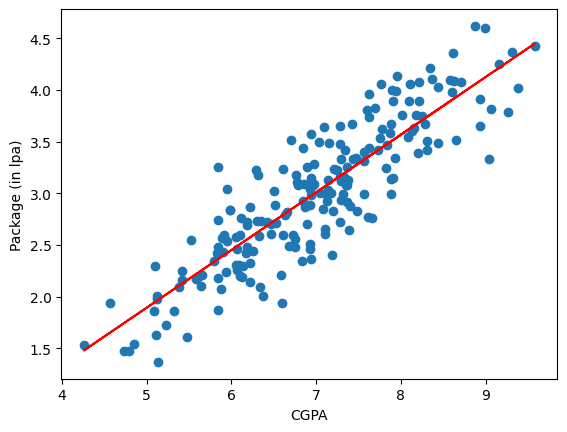

In [41]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='Red')
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa)')

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred=lr.predict(X_test)


In [44]:
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [45]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [46]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [47]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [48]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [49]:
print("R2 score",r2_score(y_test,y_pred))

R2 score 0.780730147510384


In [50]:
r2=r2_score(y_test,y_pred)

In [51]:
df.shape

(200, 2)

In [52]:
X_test.shape

(40, 1)

In [53]:
# Adjusted R2 Score

In [56]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [58]:
# By adding one additional irrelevant input column in the previous data for checkiing changes in r2_score and adjusted r2_score  

In [62]:
new_df1=df.copy()

In [63]:
new_df1['random_feature']=np.random.random(200)

In [64]:
new_df1=new_df1[['cgpa','random_feature','package']]

In [65]:
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.367127,3.26
1,5.12,0.351007,1.98
2,7.82,0.471467,3.25
3,7.42,0.047551,3.67
4,6.94,0.213494,3.57


Text(0, 0.5, 'package (in lpa)')

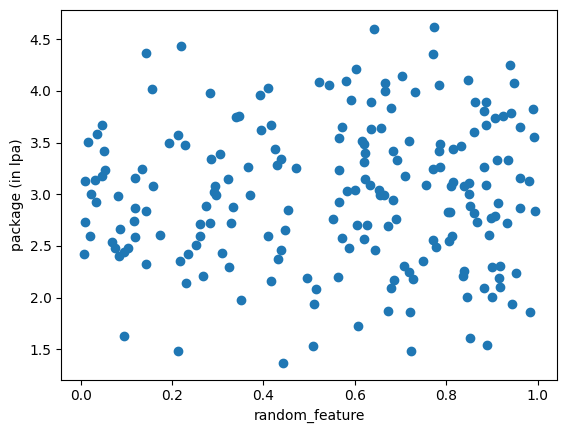

In [66]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package (in lpa)')

In [68]:
X=new_df1.iloc[:,0:2]
y=new_df1.iloc[:,-1]

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [71]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
y_pred=lr.predict(X_test)

In [73]:
print("R2 Score",r2_score(y_test,y_pred))

R2 Score 0.7793286040085249


In [74]:
r2=r2_score(y_test,y_pred)

In [75]:
#Adjusted R2 Score

In [77]:
1-((1-r2)*(40-1)/(40-1-2))

0.7674004204414181

In [82]:
# So the adjused r2 score reduced than previous as the random input column does not impacting on the output column package. 

In [83]:
# Now we add the relevant input column name iq for checking r2 score and adjusted r2 score 

In [84]:
new_df2=df.copy()

In [103]:
new_df2['iq']=new_df2['package']+(np.random.randint(-3,3,200))
new_df2=new_df2[['cgpa','iq','package']]

In [104]:
new_df2.sample(5)

,cgpa,iq,package
54,6.86,1.09,3.09
163,8.93,0.91,3.91
170,6.22,4.87,2.87
161,7.30,4.33,3.33
25,7.28,2.65,3.65


Text(0, 0.5, 'package')

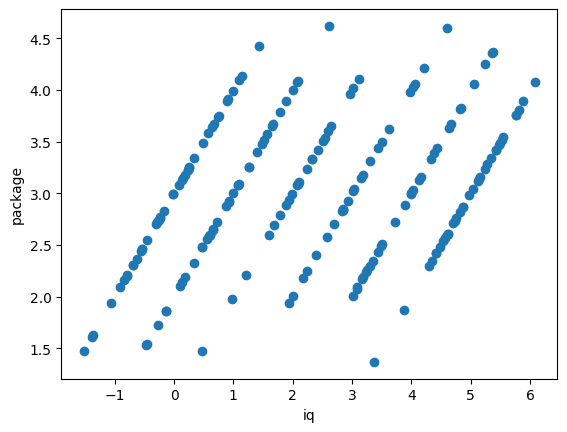

In [105]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('package')

In [106]:
np.random.randint(-100,100)

55

In [107]:
X=new_df2.iloc[:,0:2]
y=new_df2.iloc[:,-1]

In [109]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [110]:
lr=LinearRegression()

In [111]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
y_pred=lr.predict(X_test)

In [113]:
print("R2 Score",r2_score(y_test,y_pred))

R2 Score 0.8117511220994361


In [115]:
#Adjusted R2 Score
r2=r2_score(y_test,y_pred)

In [119]:
# 1-((1-r2)*(n-1)/(n-1-k))
# n is the number of rows in test data and k is the number of input columns

In [120]:
1-((1-r2)*(40-1)/(40-1-2))

0.801575507077784

In [ ]:
# here the iq column has impact on output column package as we can see adjusted r2 score increases than previous.